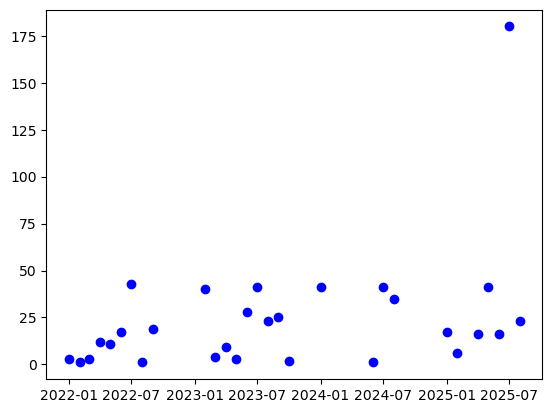

In [33]:
import matplotlib.pyplot as plt
import glob
import os
import obspy
import pandas as pd
import datetime

n_events= pd.DataFrame()
independent= list()
directories= glob.glob('/raid2/cg812/Good_earthquakes/*')
format_string= '%m.%Y'
for station in directories:
    earthquakes= glob.glob(station + '/*[!.png]')
    for event in earthquakes:
        st=obspy.read(event)
        date= st[0].stats.starttime
        date_str= str(date.month) + '.' + str(date.year)
        date_str= datetime.datetime.strptime(date_str, format_string)
        if date not in independent:
            independent.append(date)
            if date_str not in n_events:
                n_events[date_str]= [1]
            else:
                n_events[date_str]+= 1


data1 = n_events.iloc[:].T

fig, ax= plt.subplots()
ax.xaxis.axis_date()

plt.plot(data1, 'bo')
